<a href="https://colab.research.google.com/github/PadmaDeepak/ML-LAB/blob/main/lab9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Preparation for k-Means Clustering

Before applying k-Means, we need to prepare our data. This involves:

1.  **Selecting Numerical Features**: k-Means works with numerical data, so we'll extract all numerical columns from the DataFrame.
2.  **Feature Scaling**: k-Means is sensitive to the scale of the features. Features with larger values might have a disproportionately higher influence on the distance calculation. To address this, we'll scale the features using `StandardScaler`, which transforms the data to have a mean of 0 and a standard deviation of 1.

In [2]:
from sklearn.preprocessing import StandardScaler

# Select only the numerical columns for clustering
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
X = df[numerical_cols]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data (first 5 rows):")
display(pd.DataFrame(X_scaled, columns=numerical_cols).head())

Scaled data (first 5 rows):


,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


### Determining the Optimal Number of Clusters (Elbow Method)

The Elbow Method is a common technique to determine the optimal number of clusters (k) for k-Means. It plots the Within-Cluster Sum of Squares (WCSS) against the number of clusters. The 'elbow' point in the graph, where the rate of decrease in WCSS sharply changes, is often considered the optimal `k`.

We will calculate WCSS for a range of `k` values and plot them to find the elbow.

### Applying k-Means Clustering and Analyzing Results

Based on the Elbow Method, we will choose `k=3` as the optimal number of clusters. Now, we will apply the k-Means algorithm to the scaled data with this chosen `k`.

After clustering, we will:
1.  Add the cluster labels back to the original DataFrame.
2.  Display the first few rows of the DataFrame with the new cluster assignments.
3.  Show the count of observations in each cluster.

In [4]:
optimal_k = 3 # Chosen based on the Elbow Method plot

# Apply k-Means with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add the cluster labels to the original DataFrame
df['cluster'] = clusters

print(f"DataFrame with cluster assignments (first 5 rows, k={optimal_k}):")
display(df.head())

print("\nNumber of observations per cluster:")
display(df['cluster'].value_counts().sort_index())

DataFrame with cluster assignments (first 5 rows, k=3):


,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,Iris-setosa,1
1,4.9,3.0,1.4,0.2,Iris-setosa,1
2,4.7,3.2,1.3,0.2,Iris-setosa,1
3,4.6,3.1,1.5,0.2,Iris-setosa,1
4,5.0,3.6,1.4,0.2,Iris-setosa,1



Number of observations per cluster:


,count
cluster,
0,53
1,50
2,47


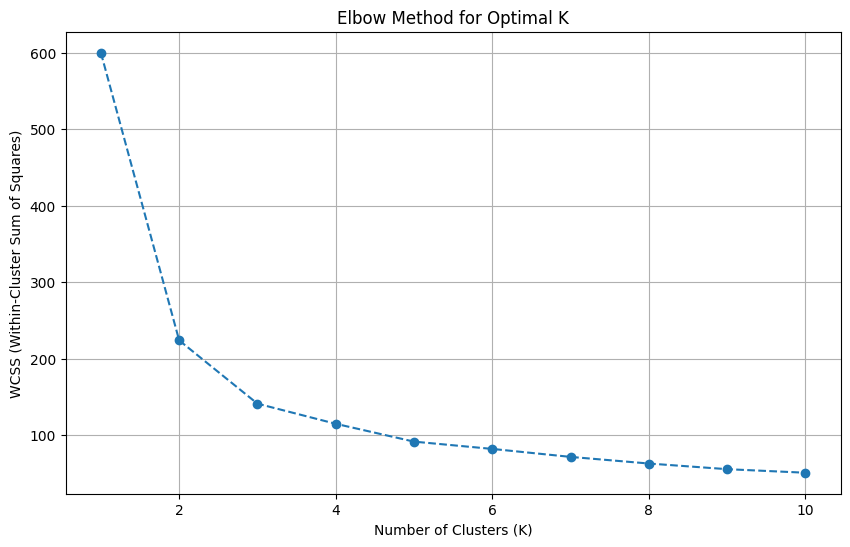

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
max_clusters = 10 # You can adjust this based on your dataset size and expected number of clusters

for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.show()

In [1]:
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('/content/iris (2) - iris (2).csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
